In [5]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
# Set styles and seeds for reproducibility
plt.style.use('seaborn-v0_8')
sns.set_palette(sns.color_palette())
np.random.seed(42)

In [53]:
def read_json_reports_into_list(file_names, directory="classification_report"):
    """
    Reads multiple JSON files, converts each report into a dictionary,
    and combines them into a list of dictionaries.
    
    Args:
        file_names (list): A list of file names (without the .json extension).
        directory (str): The directory where the JSON files are located.
        
    Returns:
        list: A list of dictionaries, where each dictionary is a model's report.
    """
    all_reports = []
    
    for name in file_names:
        file_path = os.path.join(directory, f"{name}.json")
        
        try:
            with open(file_path, 'r') as f:
                report = json.load(f)
            
            # Add the model name to the dictionary for identification later
            report['Model'] = name
            
            # Append the dictionary (JSON object) to the list
            all_reports.append(report)
            print(f"Successfully loaded report from: {name}.json")
            
        except FileNotFoundError:
            print(f"Error: File not found at {file_path}. Skipping this model.")
        except json.JSONDecodeError:
            print(f"Error: Could not decode JSON from {file_path}. Skipping this model.")
            
    return all_reports

In [54]:
model_files = {
    "lr_lab",
    "lr_scikit",
    "nn",
    "dt"
}

# 2. Execute the function to read the files
reports_array = read_json_reports_into_list(model_files)

# 3. Print the resulting array and show how to convert it to a DataFrame
print("\n--- Resulting Array (List of Dictionaries) ---")
print(json.dumps(reports_array, indent=4)) # Use json.dumps for neat printing

Successfully loaded report from: lr_scikit.json
Successfully loaded report from: dt.json
Successfully loaded report from: lr_lab.json
Successfully loaded report from: nn.json

--- Resulting Array (List of Dictionaries) ---
[
    {
        "accuracy": 0.921193232413179,
        "precision": 0.9227541502490793,
        "recall": 0.921193232413179,
        "f1-score": 0.921552580755266,
        "Model": "lr_scikit"
    },
    {
        "accuracy": 0.9020480854853072,
        "precision": 0.9032610263902038,
        "recall": 0.9020480854853072,
        "f1-score": 0.9022636111640522,
        "Model": "dt"
    },
    {
        "accuracy": 0.7880676758682101,
        "precision": 0.8258667500689281,
        "recall": 0.7880676758682101,
        "f1-score": 0.7603812018712799,
        "Model": "lr_lab"
    },
    {
        "accuracy": 0.927426536064114,
        "precision": 0.9289575667231531,
        "recall": 0.927426536064114,
        "f1-score": 0.9277211145762597,
        "Model": "nn"


    accuracy  precision     recall   f1-score      Model
0  92.119323  92.275415  92.119323  92.155258  lr_scikit
1  90.204809  90.326103  90.204809  90.226361         dt
2  78.806768  82.586675  78.806768  76.038120     lr_lab
3  92.742654  92.895757  92.742654  92.772111         nn
--- df_melted structure (Model names are preserved) ---
| Model     | Metric    |   Score |
|:----------|:----------|--------:|
| lr_scikit | accuracy  |   92.12 |
| dt        | accuracy  |   90.20 |
| lr_lab    | accuracy  |   78.81 |
| nn        | accuracy  |   92.74 |
| lr_scikit | precision |   92.28 |
| dt        | precision |   90.33 |
| lr_lab    | precision |   82.59 |
| nn        | precision |   92.90 |


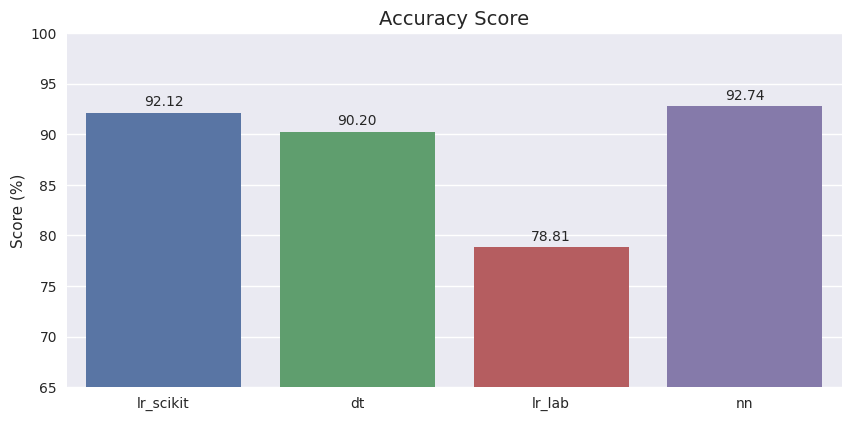

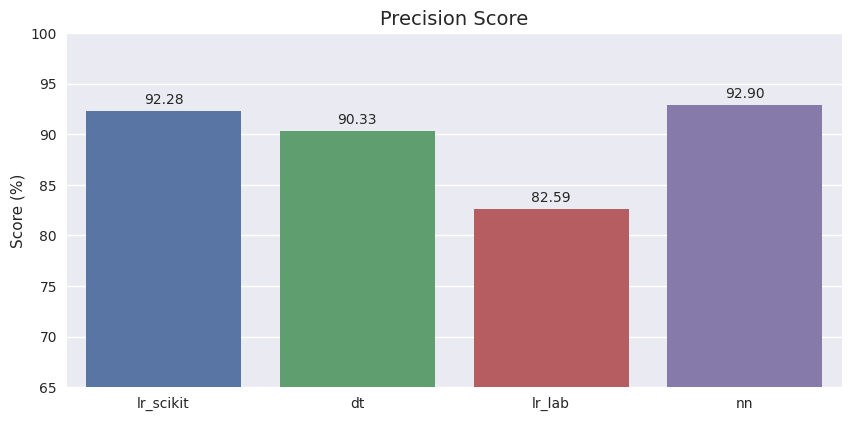

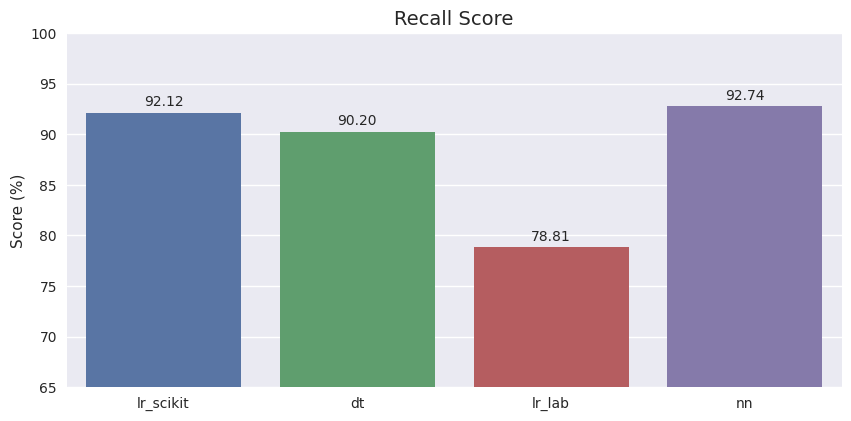

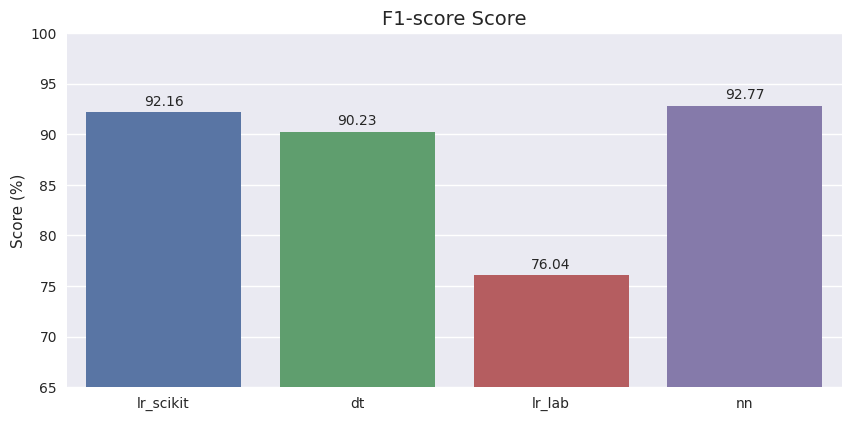

<Figure size 800x550 with 0 Axes>

In [119]:
metrics = ["accuracy", "precision", "recall", "f1-score"]

# Convert to DataFrame for easier plotting
df = pd.DataFrame(reports_array) # Transpose so models are rows
df[metrics] *= 100
# df = df.T
# df = df.reset_index().rename(columns={"index": "Metric"})

print(df)

# Melt the dataframe to make it suitable for seaborn barplots
df_melted = df.melt(id_vars="Model", var_name="Metric", value_name="Score")

print("--- df_melted structure (Model names are preserved) ---")
print(df_melted.head(8).to_markdown(index=False, floatfmt=".2f"))

# Define the color palette used for the four models:
model_colors = {
    'lr_lab': '#1f77b4',    # Blue
    'lr_scikit': '#ff7f0e', # Orange
    'nn': '#2ca02c',        # Green
    'dt': '#d62728'         # Red
}


for metric in metrics:
    # Filter data for the specific metric
    subset = df_melted[df_melted["Metric"] == metric]

    plt.figure(figsize=(10, 4.6))
    # Create Bar Plot
    ax = sns.barplot(
        data=subset, 
        x='Model', 
        y='Score', 
        hue='Model', 
        dodge=False # Prevent clustering since we only have one value per model on the x-axis
    )
    
    # Formatting
    plt.title(f'{metric.capitalize()} Score', fontsize=14)
    plt.ylim(65, 100) # Score is usually 0-1
    plt.xlabel("")
    plt.ylabel("Score (%)")
    
    # Add text labels on bars
    for container in ax.containers:
        plt.bar_label(container, fmt='%.2f', padding=3)

    plt.show()

# Add a single overall legend at the bottom
handles = [plt.Rectangle((0,0),1,1, fc=model_colors[model]) for model in model_colors]

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to fit title
plt.show()